In [1]:
import pandas as pd
import numpy as np
import os, re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    f1_score,
    log_loss
)
import joblib

In [2]:
def get_street_score(text):
    keywords = ['street', 'block', 'gang', 'money', 'hustle', 'choppa', 'glock', 'пацан', 'район', 'брат']
    if not isinstance(text, str): return 0
    text = text.lower()
    return sum(1 for word in keywords if word in text)


In [3]:
data_path = 'featured_data_1.csv'

if not os.path.exists(data_path):
    print(f"Ошибка: файл {data_path} не найден!")
else:
    df = pd.read_csv(data_path).dropna(subset=['target'])

    df['clean_lyrics'] = df['clean_lyrics'].fillna('').astype(str)
    df['street_score'] = df['clean_lyrics'].apply(get_street_score)
    df['is_trap_bpm'] = df['bpm'].apply(lambda x: 1 if (60 <= x <= 78) or (135 <= x <= 160) else 0)
    df['is_lofi_bpm'] = df['bpm'].apply(lambda x: 1 if x < 85 else 0)
    duration = df['itunes_duration_ms'].fillna(210000).replace(0, 210000) / 1000
    df['word_density'] = df['lyrics_word_count'].fillna(0) / duration
    df['power_index'] = (df['bpm'] * (df['gain'].fillna(-10) + 25)) / 100
    genre_col = 'genre_final' if 'genre_final' in df.columns else 'itunes_genre'
    df['text_combined'] = (df['track_name'].fillna('').astype(str) + " " +
                           df['artist_name'].fillna('').astype(str) + " " +
                           df[genre_col].fillna('').astype(str)).str.lower()

    num_features = ['bpm', 'gain', 'street_score', 'is_trap_bpm', 'is_lofi_bpm', 'word_density', 'power_index']
    X = df[num_features + ['text_combined']]
    y = df['target']

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    class_names = label_encoder.classes_

    print(f"\nКлассы: {class_names}")



Классы: ['Boss Fight / Doom Slayer' 'Golden Era (Old School)' 'Pilates Girl'
 'Pure Rage / Metalhead' 'Sigma Grindset' 'Zen / Lo-Fi Recovery'
 'Пацанский Вайб']


In [4]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
    )

    print(f"\nTrain: {len(X_train)} треков")
    print(f"Test: {len(X_test)} треков")
    print("-" * 60)


Train: 532 треков
Test: 133 треков
------------------------------------------------------------


In [5]:
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_features),
        ('text', TfidfVectorizer(max_features=250), 'text_combined')
    ])


In [6]:
    base_models = {
        'Random Forest': RandomForestClassifier(
            n_estimators=300, max_depth=8, min_samples_leaf=3,
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, random_state=42
        ),
        'Logistic Regression': LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1
        ),
        'SVM': SVC(
            kernel='rbf', C=1.0, gamma='scale',
            probability=True, random_state=42, class_weight='balanced'
        )
    }

    results = {}

In [7]:
    for model_name, base_model in base_models.items():
        print(f"\n--- {model_name} ---")

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', base_model)
        ])
        pipeline.fit(X_train, y_train)

        print("  Калибровка Platt Scaling...")
        calibrated_platt = CalibratedClassifierCV(
            base_model, method='sigmoid', cv=3, ensemble=False
        )
        pipeline_platt = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', calibrated_platt)
        ])
        pipeline_platt.fit(X_train, y_train)

        print("  Калибровка Isotonic Regression...")
        calibrated_isotonic = CalibratedClassifierCV(
            base_model, method='isotonic', cv=3, ensemble=False
        )
        pipeline_isotonic = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', calibrated_isotonic)
        ])
        pipeline_isotonic.fit(X_train, y_train)

        for name, pipe in [('Base', pipeline), ('Platt', pipeline_platt), ('Isotonic', pipeline_isotonic)]:
            proba = pipe.predict_proba(X_test)
            pred = pipe.predict(X_test)

            results[f"{model_name}_{name}"] = {
                'model': pipe,
                'name': f"{model_name}\n({name})",
                'balanced_acc': balanced_accuracy_score(y_test, pred),
                'f1_macro': f1_score(y_test, pred, average='macro'),
                'log_loss': log_loss(y_test, proba),
                'proba': proba,
                'pred': pred
            }


--- Random Forest ---
  Калибровка Platt Scaling...
  Калибровка Isotonic Regression...

--- Gradient Boosting ---
  Калибровка Platt Scaling...
  Калибровка Isotonic Regression...

--- Logistic Regression ---
  Калибровка Platt Scaling...
  Калибровка Isotonic Regression...


C:\Users\кошька\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\кошька\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\кошька\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\кошька\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning


--- SVM ---
  Калибровка Platt Scaling...
  Калибровка Isotonic Regression...


In [8]:
    best_model_key = min(results.keys(), key=lambda k: results[k]['log_loss'])
    best = results[best_model_key]

    print(f"\nЛучшая модель: {best['name']}")
    print(f"   Log Loss: {best['log_loss']:.4f}")
    print(f"   Balanced Accuracy: {best['balanced_acc']:.4f}")

    base_model_key = best_model_key.replace('_Platt', '_Base').replace('_Isotonic', '_Base')
    if base_model_key in results:
        base = results[base_model_key]
    else:
        base = best


Лучшая модель: Gradient Boosting
(Platt)
   Log Loss: 0.5828
   Balanced Accuracy: 0.8111



1. Построение калибровочных кривых...


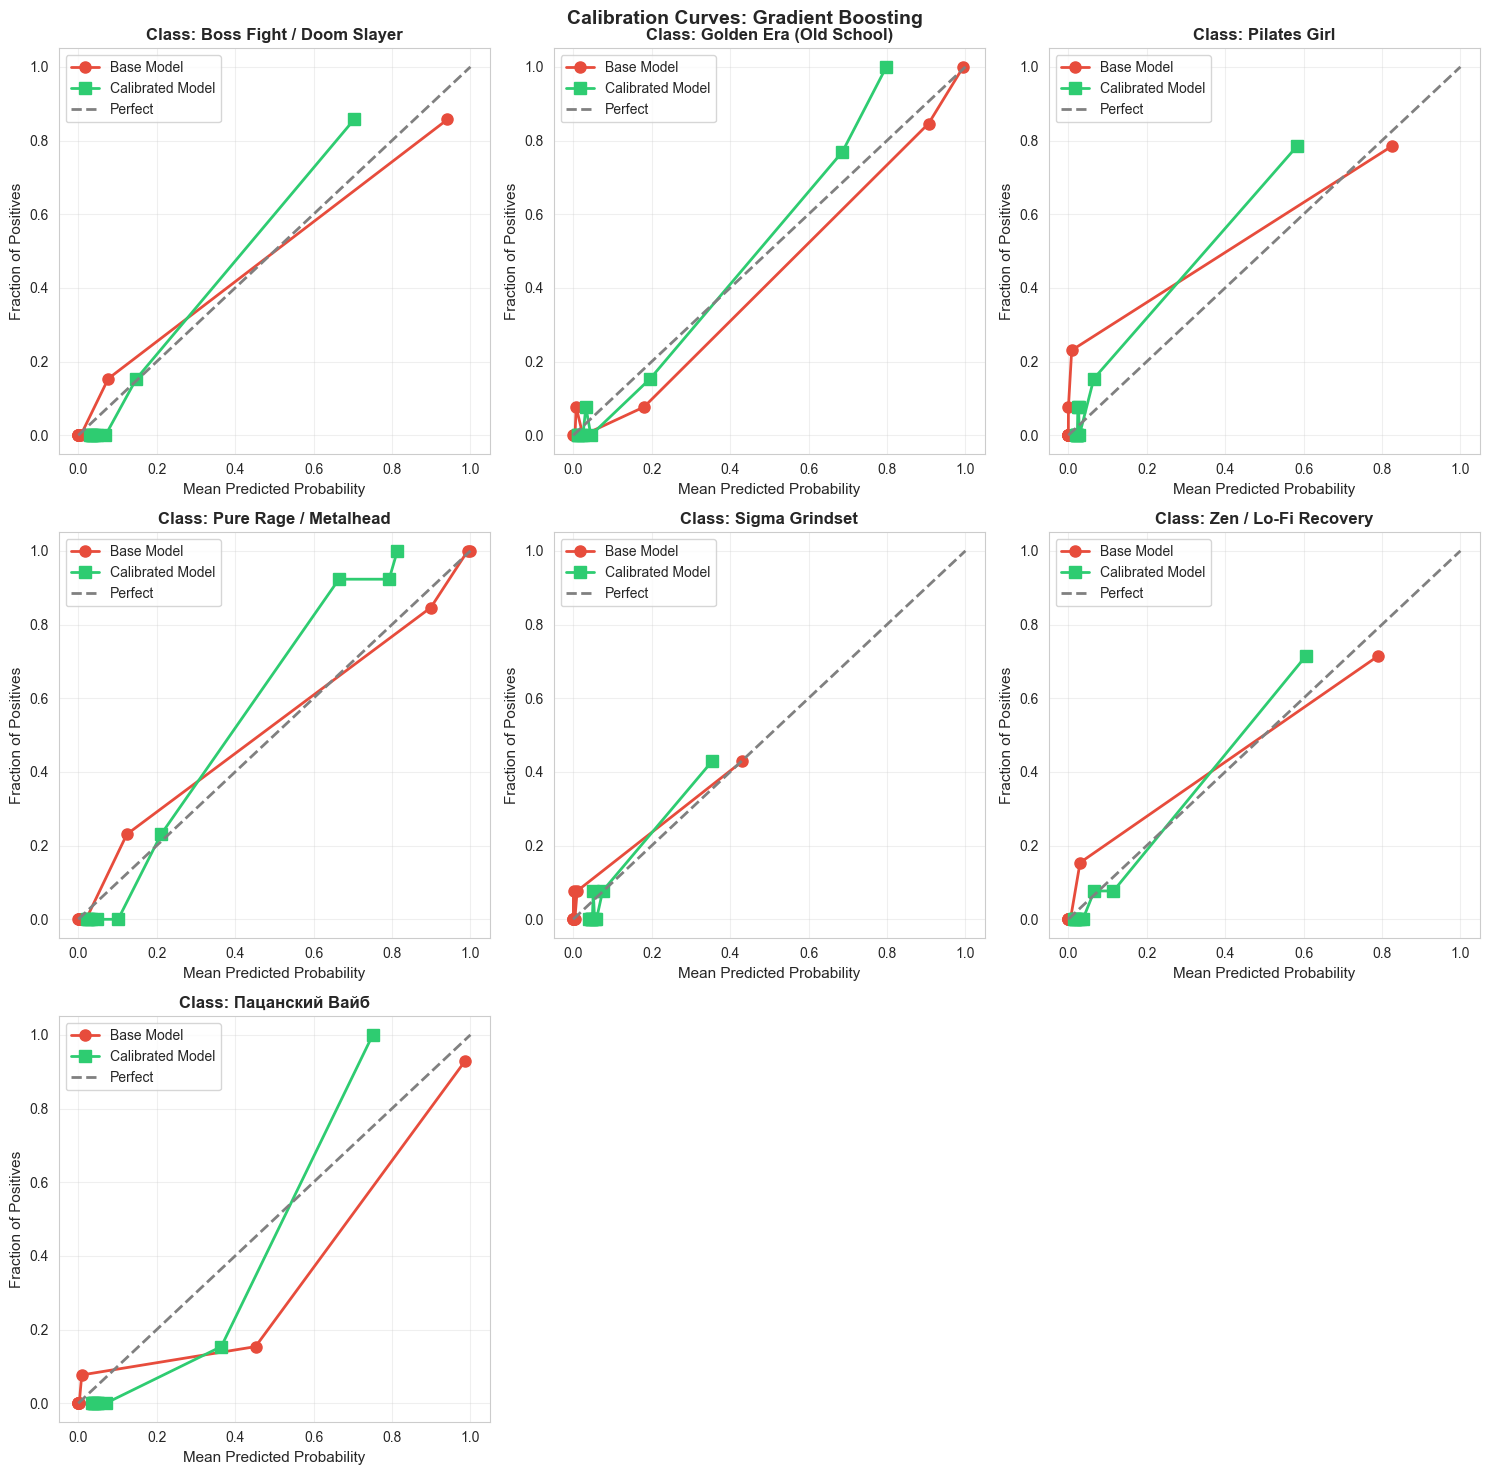

In [9]:
    print("\n1. Построение калибровочных кривых...")

    n_classes = len(class_names)
    n_cols = min(3, n_classes)
    n_rows = (n_classes + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    if n_classes == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for class_idx in range(n_classes):
        ax = axes[class_idx]
        y_true_binary = (y_test == class_idx).astype(int)

        prob_true_base, prob_pred_base = calibration_curve(
            y_true_binary, base['proba'][:, class_idx],
            n_bins=10, strategy='quantile'
        )
        ax.plot(prob_pred_base, prob_true_base, 'o-', linewidth=2,
                markersize=8, label='Base Model', color='#E74C3C')

        prob_true_best, prob_pred_best = calibration_curve(
            y_true_binary, best['proba'][:, class_idx],
            n_bins=10, strategy='quantile'
        )
        ax.plot(prob_pred_best, prob_true_best, 's-', linewidth=2,
                markersize=8, label='Calibrated Model', color='#2ECC71')

        ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=2, label='Perfect')

        class_label = class_names[class_idx] if len(class_names) > class_idx else f'Class {class_idx}'
        ax.set_title(f'Class: {class_label}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Mean Predicted Probability', fontsize=11)
        ax.set_ylabel('Fraction of Positives', fontsize=11)
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)

    for idx in range(n_classes, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Calibration Curves: {best["name"].split("(")[0].strip()}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('calibration_curves.png', dpi=300, bbox_inches='tight')
    plt.show()



2. Построение гистограмм уверенности...


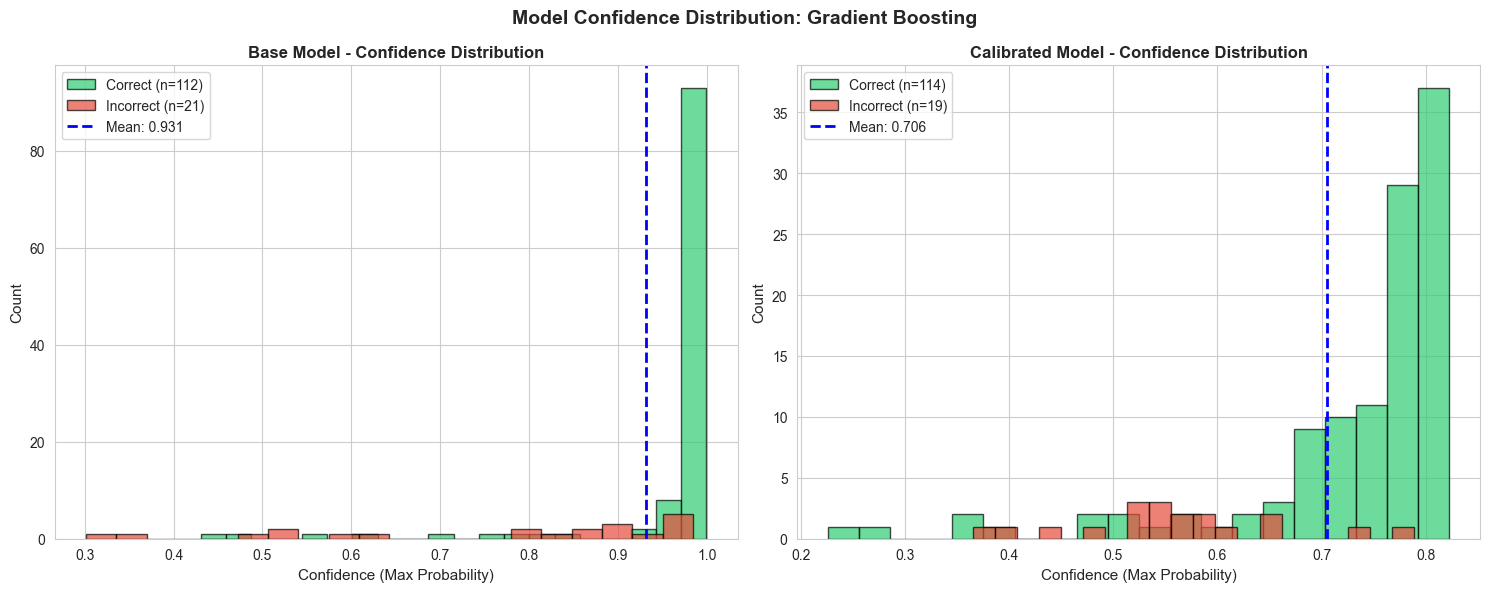

In [10]:
    print("\n2. Построение гистограмм уверенности...")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    max_base = np.max(base['proba'], axis=1)
    max_best = np.max(best['proba'], axis=1)

    correct_base = (base['pred'] == y_test)
    correct_best = (best['pred'] == y_test)

    axes[0].hist(max_base[correct_base], bins=20, alpha=0.7,
                 label=f'Correct (n={correct_base.sum()})',
                 color='#2ECC71', edgecolor='black')
    axes[0].hist(max_base[~correct_base], bins=20, alpha=0.7,
                 label=f'Incorrect (n={(~correct_base).sum()})',
                 color='#E74C3C', edgecolor='black')
    axes[0].set_title(f"Base Model - Confidence Distribution", fontweight='bold', fontsize=12)
    axes[0].set_xlabel("Confidence (Max Probability)", fontsize=11)
    axes[0].set_ylabel("Count", fontsize=11)
    axes[0].axvline(max_base.mean(), color='blue', linestyle='--',
                    linewidth=2, label=f'Mean: {max_base.mean():.3f}')
    axes[0].legend(loc='upper left', fontsize=10)

    axes[1].hist(max_best[correct_best], bins=20, alpha=0.7,
                 label=f'Correct (n={correct_best.sum()})',
                 color='#2ECC71', edgecolor='black')
    axes[1].hist(max_best[~correct_best], bins=20, alpha=0.7,
                 label=f'Incorrect (n={(~correct_best).sum()})',
                 color='#E74C3C', edgecolor='black')
    axes[1].set_title(f"Calibrated Model - Confidence Distribution", fontweight='bold', fontsize=12)
    axes[1].set_xlabel("Confidence (Max Probability)", fontsize=11)
    axes[1].set_ylabel("Count", fontsize=11)
    axes[1].axvline(max_best.mean(), color='blue', linestyle='--',
                    linewidth=2, label=f'Mean: {max_best.mean():.3f}')
    axes[1].legend(loc='upper left', fontsize=10)

    plt.suptitle(f'Model Confidence Distribution: {best["name"].split("(")[0].strip()}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('confidence_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()



3. Построение графика сравнения метрик...


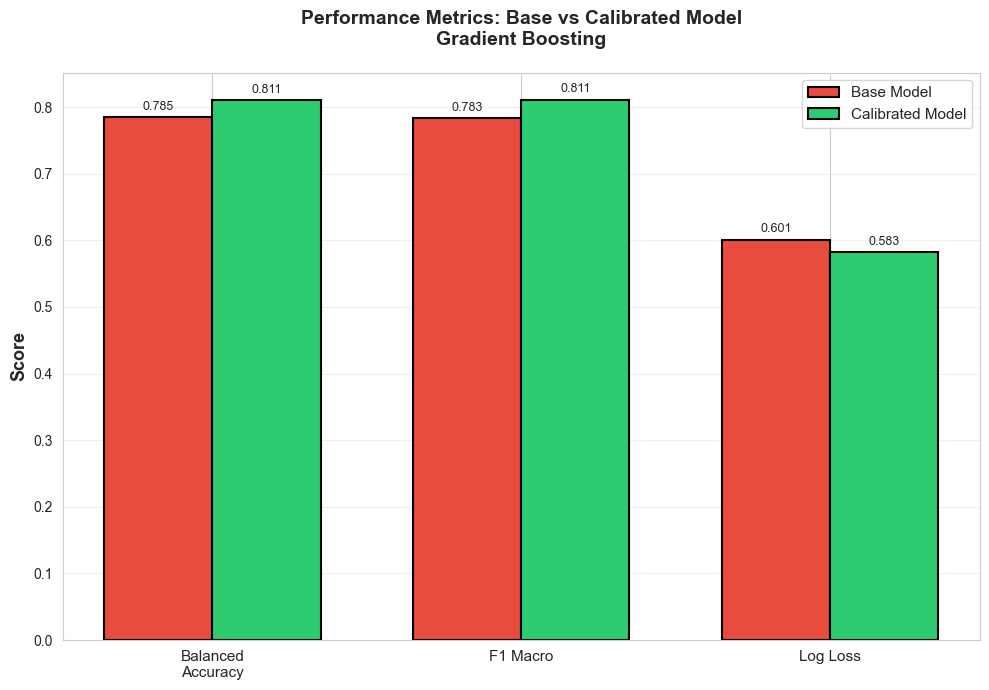

In [11]:
    print("\n3. Построение графика сравнения метрик...")

    fig, ax = plt.subplots(figsize=(10, 7))

    metrics_data = {
        'Balanced\nAccuracy': [base['balanced_acc'], best['balanced_acc']],
        'F1 Macro': [base['f1_macro'], best['f1_macro']],
        'Log Loss': [base['log_loss'], best['log_loss']]
    }

    x = np.arange(len(metrics_data))
    width = 0.35

    bars1 = ax.bar(x - width / 2, [metrics_data[k][0] for k in metrics_data.keys()],
                   width, label='Base Model', color='#E74C3C', edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width / 2, [metrics_data[k][1] for k in metrics_data.keys()],
                   width, label='Calibrated Model', color='#2ECC71', edgecolor='black', linewidth=1.5)

    ax.set_ylabel('Score', fontsize=13, fontweight='bold')
    ax.set_title(f'Performance Metrics: Base vs Calibrated Model\n{best["name"].split("(")[0].strip()}',
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_data.keys(), fontsize=11)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


In [12]:
    print(" ИТОГОВЫЙ ОТЧЕТ ПО КАЛИБРОВКЕ ")

    print(f"""
    ЛУЧШАЯ МОДЕЛЬ: {best['name']}

    МЕТРИКИ:
    ┌─────────────────────┬──────────────┬──────────────────┐
    │ Метрика             │ Base Model   │ Calibrated Model │
    ├─────────────────────┼──────────────┼──────────────────┤
    │ Balanced Accuracy   │ {base['balanced_acc']:.4f}       │ {best['balanced_acc']:.4f}            │
    │ F1 Macro            │ {base['f1_macro']:.4f}       │ {best['f1_macro']:.4f}            │
    │ Log Loss            │ {base['log_loss']:.4f}       │ {best['log_loss']:.4f}            │
    └─────────────────────┴──────────────┴──────────────────┘

    УЛУЧШЕНИЕ:
    • Log Loss: {base['log_loss'] - best['log_loss']:+.4f}

    СОХРАНЕННЫЕ ФАЙЛЫ:
    1. calibration_curves.png - калибровочные кривые по классам
    2. confidence_histograms.png - гистограммы уверенности
    3. metrics_comparison.png - сравнение метрик
    4. best_calibrated_model.pkl - лучшая модель
    """)

    joblib.dump({
        'pipeline': best['model'],
        'label_encoder': label_encoder,
        'class_names': class_names,
        'model_name': best['name'],
        'metrics': {
            'balanced_accuracy': best['balanced_acc'],
            'f1_macro': best['f1_macro'],
            'log_loss': best['log_loss']
        }
    }, 'best_calibrated_model.pkl')

    print(f"\nЛучшая модель сохранена в 'best_calibrated_model.pkl'")

 ИТОГОВЫЙ ОТЧЕТ ПО КАЛИБРОВКЕ 

ЛУЧШАЯ МОДЕЛЬ: Gradient Boosting
(Platt)

МЕТРИКИ:
┌─────────────────────┬──────────────┬──────────────────┐
│ Метрика             │ Base Model   │ Calibrated Model │
├─────────────────────┼──────────────┼──────────────────┤
│ Balanced Accuracy   │ 0.7854       │ 0.8111            │
│ F1 Macro            │ 0.7832       │ 0.8112            │
│ Log Loss            │ 0.6011       │ 0.5828            │
└─────────────────────┴──────────────┴──────────────────┘

УЛУЧШЕНИЕ:
• Log Loss: +0.0183

СОХРАНЕННЫЕ ФАЙЛЫ:
1. calibration_curves.png - калибровочные кривые по классам
2. confidence_histograms.png - гистограммы уверенности
3. metrics_comparison.png - сравнение метрик
4. best_calibrated_model.pkl - лучшая модель


Лучшая модель сохранена в 'best_calibrated_model.pkl'
